# Hands-on: Multi-Period Difference-in-Differences with DoubleML
## Understanding the Framework

In this notebook, we use synthetic data with known treatment effects to build intuition for the [DoubleML](https://docs.doubleml.org/stable/index.html) multi-period Difference-in-Differences (DiD) framework. The implementation is based on [Callaway and Sant'Anna (2021)](https://doi.org/10.1016/j.jeconom.2020.12.001).

Because the data-generating process (DGP) provides oracle potential outcomes, we can directly verify our estimates against ground truth. We estimate group-time average treatment effects on the treated ($ATT$), explore aggregation schemes, and compare methodological choices.

### Learning Objectives

1. **Understand the DGP** for staggered DiD and interpret the panel data structure (groups, time periods, covariates, potential outcomes)
2. **Estimate group-time ATTs** using `DoubleMLDIDMulti` and compare against known oracle values
3. **Apply and interpret aggregation schemes** (group, calendar time, event study) and understand their weighting structure
4. **Explore methodological choices**: control groups (`never_treated` vs. `not_yet_treated`), learner specification (linear vs. nonlinear), and `gt_combinations`

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

from lightgbm import LGBMRegressor, LGBMClassifier

from doubleml.did import DoubleMLDIDMulti
from doubleml.data import DoubleMLPanelData
from doubleml.did.datasets import make_did_CS2021

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
  
warnings.filterwarnings(
    "ignore",
    message=".*X does not have valid feature names, but LGBM.* was fitted with feature names",
    category=UserWarning,
)

### Key Notation Recap

Recall from the lecture the core notation for multi-period DiD:

- **Group-time ATT**: $ATT(\mathrm{g}, t_{\text{eval}}) = \mathbb{E}[Y_{t_{\text{eval}}}(\mathrm{g}) - Y_{t_{\text{eval}}}(0) \mid G_i = \mathrm{g}]$ is the average treatment effect on units first treated in period $\mathrm{g}$, evaluated at period $t_{\text{eval}}$.
- **Group** $\mathrm{g}$: the first treatment period; $G_i = \text{NaT}$ (or $\infty$) for never-treated units.
- **Nuisance: Conditional Trend** $g_0(X_i) = \mathbb{E}[Y_{i,t_{\text{eval}}} - Y_{i,t_{\text{pre}}} \mid X_i, G_i \in \mathcal{C}]$: the outcome trend for the control group.
- **Nuisance: Propensity Score** $m_0(X_i) = P(G_i = \mathrm{g} \mid X_i, G_i \in \{\mathrm{g}, \mathcal{C}\})$: the probability of belonging to group $\mathrm{g}$.
- The **doubly robust score** requires estimation of both nuisance components via cross-fitting.

## 1. Data Generation and Exploration

We use the `make_did_CS2021` DGP, which is inspired by [Callaway and Sant'Anna (2021)](https://doi.org/10.1016/j.jeconom.2020.12.001) (Appendix SC) and [Sant'Anna and Zhao (2020)](https://doi.org/10.1016/j.jeconom.2020.06.003). The DGP generates potential outcomes $Y_{i,t}(0)$ and $Y_{i,t}(1)$, such that the true individual treatment effect (ITE) is observable for oracle comparison.

We use `dgp_type=4`, which features nonlinear conditional expectations.

In [2]:
n_obs = 5000
n_periods = 6

np.random.seed(42)
df = make_did_CS2021(
    n_obs, dgp_type=4, n_periods=n_periods,
    n_pre_treat_periods=3, time_type="datetime"
)
df["ite"] = df["y1"] - df["y0"]

print(f"Shape: {df.shape}")
df.head()

Shape: (30000, 11)


,id,y,y0,y1,d,t,Z1,Z2,Z3,Z4,ite
0,0,217.827145,217.827145,219.640708,2025-04-01,2025-01-01,0.21216,-0.102127,0.250056,0.976466,1.813563
1,0,226.704643,226.704643,227.218944,2025-04-01,2025-02-01,0.21216,-0.102127,0.250056,0.976466,0.514301
2,0,233.212740,233.212740,234.800400,2025-04-01,2025-03-01,0.21216,-0.102127,0.250056,0.976466,1.587659
3,0,243.469759,242.285857,243.469759,2025-04-01,2025-04-01,0.21216,-0.102127,0.250056,0.976466,1.183902
4,0,251.857401,249.775634,251.857401,2025-04-01,2025-05-01,0.21216,-0.102127,0.250056,0.976466,2.081767


### Data-Generating Process

The DGP follows the structure:

$$
\begin{align*}
Y_{i,t}(0) &= f_t(Z) + \delta_t + \eta_i + \varepsilon_{i,t,0} \\
Y_{i,t}(1) &= Y_{i,t}(0) + \theta_{i,t,\mathrm{g}} + \varepsilon_{i,t,1} - \varepsilon_{i,t,0}
\end{align*}
$$

where
- $f_t(Z)$ depends on pre-treatment covariates $Z_1, \dots, Z_4$ and time (nonlinear for `dgp_type=4`)
- $\delta_t$ is a time fixed effect
- $\eta_i$ is a unit fixed effect
- $\varepsilon_{i,t,\cdot} \sim N(0,1)$ are time-varying unobservables
- $\theta_{i,t,\mathrm{g}} = 0$ for $t < \mathrm{g}$ (no pre-treatment effects by construction) such that $\mathbb{E}[Y_{i,t}(1) - Y_{i,t}(0)] = \mathbb{E}[\epsilon_{i,t,1} - \epsilon_{i,t,0}]=0  \text{ for } t<\mathrm{g}$

The true treatment effect equals the exposure time: $ATT(\mathrm{g}, t) = t - \mathrm{g} + 1$ for $t \geq \mathrm{g}$.

**Columns:** `id` (unit), `y` (observed outcome), `y0`/`y1` (potential outcomes), `d` (first treatment period, `NaT` = never treated), `t` (time), `Z1`-`Z4` (pre-treatment covariates), `ite` (individual treatment effect).

### Panel Structure and Treatment Groups

In [3]:
# Confirm balanced panel
df.groupby("t").size()

t
2025-01-01    5000
2025-02-01    5000
2025-03-01    5000
2025-04-01    5000
2025-05-01    5000
2025-06-01    5000
dtype: int64

In [4]:
# Treatment group distribution
# NaT = never treated; other values = first treatment period
df.groupby(["t","d"], dropna=False).size()

t           d         
2025-01-01  2025-04-01    1298
            2025-05-01    1268
            2025-06-01    1193
            NaT           1241
2025-02-01  2025-04-01    1298
            2025-05-01    1268
            2025-06-01    1193
            NaT           1241
2025-03-01  2025-04-01    1298
            2025-05-01    1268
            2025-06-01    1193
            NaT           1241
2025-04-01  2025-04-01    1298
            2025-05-01    1268
            2025-06-01    1193
            NaT           1241
2025-05-01  2025-04-01    1298
            2025-05-01    1268
            2025-06-01    1193
            NaT           1241
2025-06-01  2025-04-01    1298
            2025-05-01    1268
            2025-06-01    1193
            NaT           1241
dtype: int64

In [5]:
# Prepare data for plotting
df["First Treated"] = df["d"].dt.strftime("%Y-%m").fillna("Never Treated")

def agg_dict(col_name):
    return {
        f'{col_name}_mean': (col_name, 'mean'),
        f'{col_name}_lower_quantile': (col_name, lambda x: x.quantile(0.05)),
        f'{col_name}_upper_quantile': (col_name, lambda x: x.quantile(0.95))
    }

agg_dictionary = agg_dict("y") | agg_dict("ite")
agg_df = df.groupby(["t", "First Treated"]).agg(**agg_dictionary).reset_index()
agg_df.head()

,t,First Treated,y_mean,y_lower_quantile,y_upper_quantile,ite_mean,ite_lower_quantile,ite_upper_quantile
0,2025-01-01,2025-04,208.876194,199.079532,219.074392,0.031911,-2.286308,2.343234
1,2025-01-01,2025-05,210.466406,200.582756,220.695822,-0.045019,-2.354394,2.260598
2,2025-01-01,2025-06,212.542859,202.749628,223.086231,-0.029749,-2.355304,2.314842
3,2025-01-01,Never Treated,214.630152,204.423351,224.328424,-0.005142,-2.326741,2.251644
4,2025-02-01,2025-04,208.744003,189.813347,228.776932,0.057692,-2.302891,2.398111


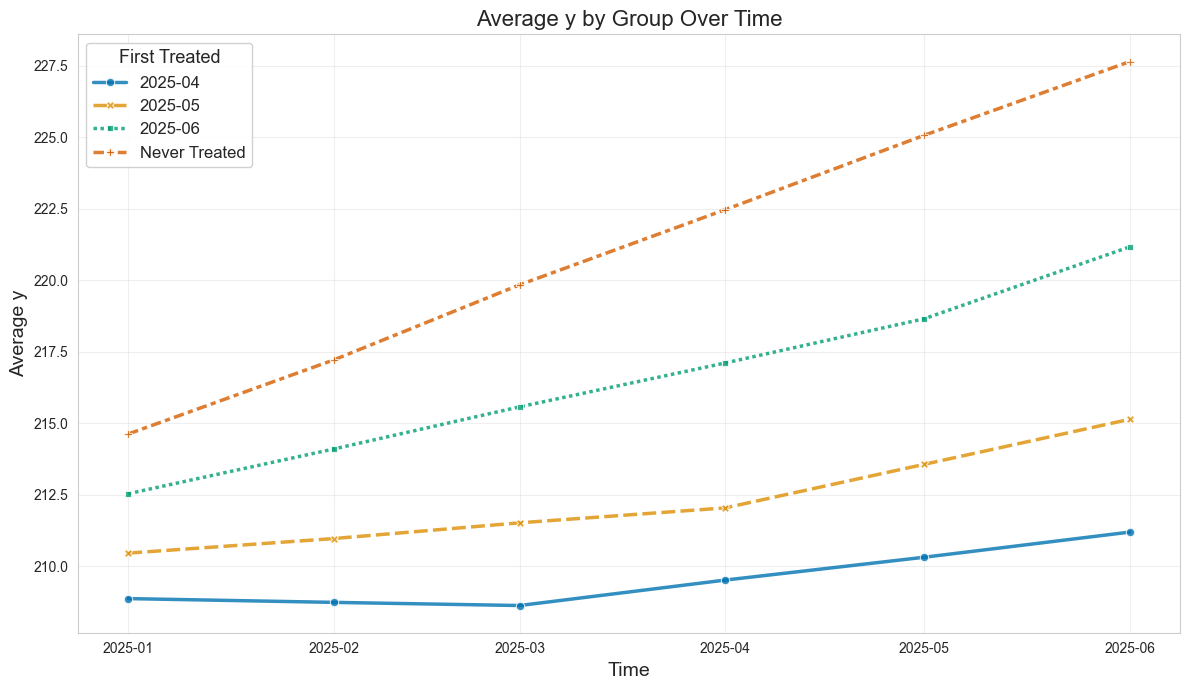

In [6]:
def plot_data(df, col_name='y'):
    """Plot group-level averages over time with colorblind-friendly palette."""
    plt.figure(figsize=(12, 7))
    n_colors = df["First Treated"].nunique()
    color_palette = sns.color_palette("colorblind", n_colors=n_colors)

    sns.lineplot(
        data=df, x='t', y=f'{col_name}_mean',
        hue='First Treated', style='First Treated',
        palette=color_palette, markers=True, dashes=True,
        linewidth=2.5, alpha=0.8
    )
    plt.title(f'Average {col_name} by Group Over Time', fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel(f'Average {col_name}', fontsize=14)
    plt.legend(title='First Treated', title_fontsize=13, fontsize=12,
               frameon=True, framealpha=0.9, loc='best')
    plt.grid(alpha=0.3, linestyle='-')
    plt.tight_layout()
    plt.show()

# Average observed outcomes by group
plot_data(agg_df, col_name='y')

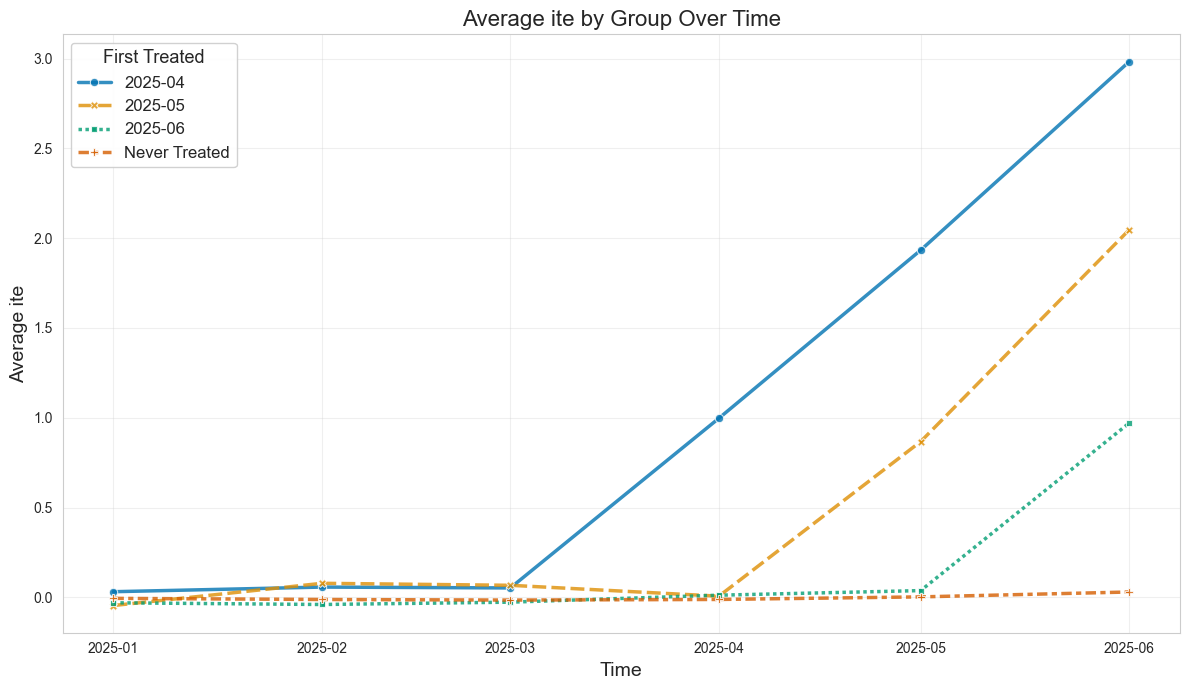

In [7]:
# Oracle: True average ITEs by group
plot_data(agg_df, col_name='ite')

The first plot shows non-parallel trends across groups because treatment assignment depends on $Z$. Looking at raw group-mean differences would produce biased estimates.

The second oracle plot reveals the ground truth: zero effects in pre-treatment periods, then effects that increase linearly with exposure time ($ATT(\mathrm{g},t) = t - \mathrm{g} + 1$ months). This oracle is what we will evaluate our estimates against.

### Oracle Values

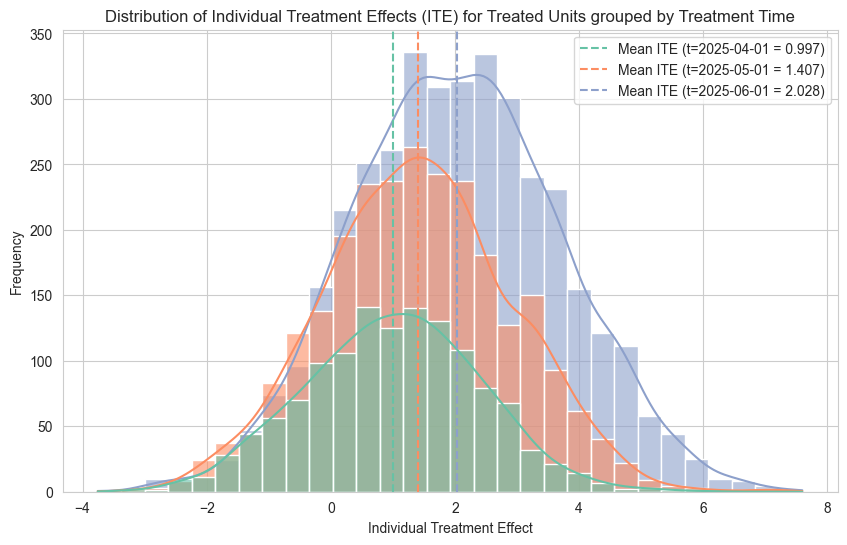

In [8]:
# 1. Get unique dates and create a dictionary mapping them to colors
unique_t = sorted(df[df["t"] >= df["d"]]["t"].unique())
colors = sns.color_palette("Set2", n_colors=len(unique_t))
color_map = dict(zip(unique_t, colors))  # e.g., {'2025-05-01': (0.1, 0.2, 0.5), ...}
# 2. Use 'color_map' in histplot instead of the list 'colors'
sns.histplot(data=df[df["t"] >= df["d"]], x="ite", hue="t", bins=30, kde=True, palette=color_map, alpha=0.6, legend=True)
# 3. In the loop, look up the color using the dictionary
mean_ite = df[df["t"] >= df["d"]].groupby("t")["ite"].mean()
# Remove 'enumerate' and just iterate items
for t_value, mean in mean_ite.items():
    # Use color_map[t_value] to guarantee the same color as the histogram
    plt.axvline(mean, color=color_map[t_value], linestyle="--", label=f"Mean ITE (t={t_value.strftime('%Y-%m-%d')} = {mean:.3f})")
plt.legend()
plt.title("Distribution of Individual Treatment Effects (ITE) for Treated Units grouped by Treatment Time")
plt.xlabel("Individual Treatment Effect")
plt.ylabel("Frequency")
plt.show()

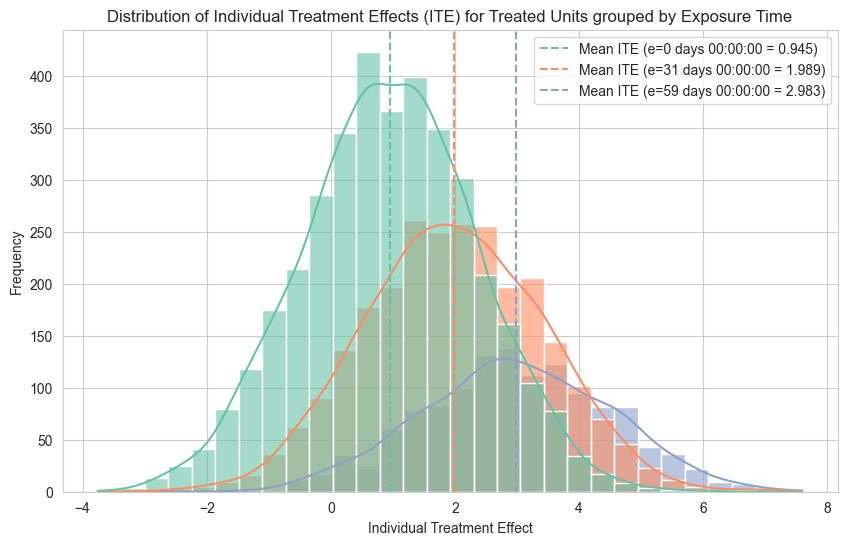

In [9]:
df["e"] = pd.to_datetime(df["t"]).values.astype("datetime64[M]") - \
    pd.to_datetime(df["d"]).values.astype("datetime64[M]")

unique_e = sorted(df[df["t"] >= df["d"]]["e"].unique())
colors = sns.color_palette("Set2", n_colors=len(unique_e))
color_map = dict(zip(unique_e, colors))  # e.g., {'2025-05-01': (0.1, 0.2, 0.5), ...}
# 2. Use 'color_map' in histplot instead of the list 'colors'
sns.histplot(data=df[df["t"] >= df["d"]], x="ite", hue="e", bins=30, kde=True, palette=color_map, alpha=0.6, legend=True)
# 3. In the loop, look up the color using the dictionary
mean_ite = df[df["t"] >= df["d"]].groupby("e")["ite"].mean()
# Remove 'enumerate' and just iterate items
for e_value, mean in mean_ite.items():
    # Use color_map[e_value] to guarantee the same color as the histogram
    plt.axvline(mean, color=color_map[e_value], linestyle="--", label=f"Mean ITE (e={e_value} = {mean:.3f})")
plt.legend()
plt.title("Distribution of Individual Treatment Effects (ITE) for Treated Units grouped by Exposure Time")
plt.xlabel("Individual Treatment Effect")
plt.ylabel("Frequency")
plt.show()

## 2. Panel Data Backend: `DoubleMLPanelData`

To use DoubleML for panel DiD, data must be organized into a `DoubleMLPanelData` object. Required arguments:

- `y_col`: outcome column
- `d_cols`: group variable (first treatment period; `NaT` or `np.inf` for never-treated)
- `id_col`: unit identifier
- `t_col`: time column
- `x_cols`: pre-treatment covariate column names
- `datetime_unit`: required for `datetime` columns and plotting (e.g., `"M"` for months)

In [10]:
dml_data = DoubleMLPanelData(
    data=df,
    y_col="y",
    d_cols="d",
    id_col="id",
    t_col="t",
    x_cols=["Z1", "Z2", "Z3", "Z4"],
    datetime_unit="M"
)
print(dml_data)

================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['Z1', 'Z2', 'Z3', 'Z4']
Instrument variable(s): None
Time variable: t
Id variable: id
Static panel data: False
No. Unique Ids: 5000
No. Observations: 30000
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Columns: 13 entries, id to e
dtypes: datetime64[s](2), float64(8), int64(1), str(1), timedelta64[s](1)
memory usage: 3.0 MB



The output confirms: 5000 unique units, 30000 total observations (5000 $\times$ 6 periods), and the specified outcome, treatment, and covariate columns.

## 3. Estimating Group-Time ATTs

The `DoubleMLDIDMulti` class estimates group-time average treatment effects using doubly robust scores with cross-fitted ML nuisance estimation. Key arguments:

- `ml_g`: regression learner for the outcome nuisance $g_0(X_i)$
- `ml_m`: classification learner for the propensity score $m_0(X_i)$
- `control_group`: `"never_treated"` or `"not_yet_treated"`
- `gt_combinations`: which $(\mathrm{g}, t_{\text{pre}}, t_{\text{eval}})$ triples to estimate (`"standard"`, `"all"`, `"universal"`, or a custom list)
- `anticipation_periods`: number of anticipation periods $\delta$ (default 0)
- `n_folds`: number of cross-fitting folds

For details, see the [model documentation](https://docs.doubleml.org/stable/guide/models.html#difference-in-differences-models-did) and [score documentation](https://docs.doubleml.org/stable/guide/scores.html#difference-in-differences-models).

In [11]:
default_args = {
    "ml_g": LGBMRegressor(n_estimators=500, learning_rate=0.01, verbose=-1, random_state=123),
    "ml_m": LGBMClassifier(n_estimators=500, learning_rate=0.01, verbose=-1, random_state=123),
    "control_group": "never_treated",
    "gt_combinations": "standard",
    "anticipation_periods": 0,
    "n_folds": 5,
    "n_rep": 1,
}

In [12]:
np.random.seed(42)
dml_obj = DoubleMLDIDMulti(dml_data, **default_args)
dml_obj.fit(store_models=True)
print(dml_obj.summary.round(4))

/Users/ruizhechao/Documents/ds-inflow-price-elasticity-service/DoubleML/.venv/lib/python3.12/site-packages/doubleml/double_ml.py:1636: UserWarning: The estimated nu2 for d is not positive. Re-estimation based on riesz representer (non-orthogonal).
  warnings.warn(msg, UserWarning)


                                coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2025-04,2025-01,2025-02) -0.0191   0.1712  -0.1113  0.9114 -0.3545  0.3164
ATT(2025-04,2025-02,2025-03) -0.0011   0.1024  -0.0110  0.9913 -0.2018  0.1996
ATT(2025-04,2025-03,2025-04)  0.8713   0.1282   6.7955  0.0000  0.6200  1.1226
ATT(2025-04,2025-03,2025-05)  1.7434   0.1808   9.6427  0.0000  1.3890  2.0977
ATT(2025-04,2025-03,2025-06)  2.3872   0.2757   8.6602  0.0000  1.8469  2.9275
ATT(2025-05,2025-01,2025-02) -0.0124   0.1184  -0.1048  0.9165 -0.2446  0.2197
ATT(2025-05,2025-02,2025-03)  0.0900   0.0986   0.9126  0.3614 -0.1033  0.2834
ATT(2025-05,2025-03,2025-04) -0.0084   0.1251  -0.0674  0.9463 -0.2535  0.2367
ATT(2025-05,2025-04,2025-05)  1.0686   0.1217   8.7824  0.0000  0.8301  1.3071
ATT(2025-05,2025-04,2025-06)  1.9317   0.1674  11.5391  0.0000  1.6036  2.2598
ATT(2025-06,2025-01,2025-02)  0.0658   0.1009   0.6521  0.5143 -0.1320  0.2637
ATT(2025-06,2025-02,2025-03) -0.0361   0.0967  -0.37

### Hyperparameter Tuning with Optuna

The default LightGBM hyperparameters were chosen conservatively. DoubleML integrates with [Optuna](https://optuna.org/) for automated hyperparameter tuning via the `tune_ml_models()` method.

Instead of a fixed grid, we define callable parameter spaces that use Optuna's `trial.suggest_*` API to define search distributions. The method then performs Bayesian optimization to find hyperparameters that minimize cross-validated nuisance loss (RMSE for `ml_g`, log loss for `ml_m`).

For details, see the [DoubleML Optuna tuning guide](https://docs.doubleml.org/stable/examples/learners/py_optuna.html).

In [13]:
import optuna
from plotly.io import show

# Suppress Optuna logs during tuning
optuna.logging.set_verbosity(optuna.logging.WARNING)

#### Nuisance Performance Before Tuning

Before tuning, let's record the out-of-sample nuisance model performance. The model's `print()` output shows RMSE for `ml_g` (outcome regression) and log loss for `ml_m` (propensity score) for each group-time combination.

In [14]:
# Nuisance model diagnostics with default hyperparameters
# The output shows RMSE (ml_g) and log loss (ml_m) for each group-time combination
print(dml_obj)

================== DoubleMLDIDMulti Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['Z1', 'Z2', 'Z3', 'Z4']
Instrument variable(s): None
Time variable: t
Id variable: id
Static panel data: False
No. Unique Ids: 5000
No. Observations: 30000
------------------ Score & algorithm ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0

------------------ Machine learner   ------------------
Learner ml_g: LGBMRegressor(learning_rate=0.01, n_estimators=500, random_state=123,
              verbose=-1)
Learner ml_m: LGBMClassifier(learning_rate=0.01, n_estimators=500, random_state=123,
               verbose=-1)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[1.96713388 1.90304977 1.95404211 2.99782753 4.11132267 1.98645554
  1.92607639 1.93039827 1.94990471 2.88002672 1.95771906 1.98777986
  1.97505098 1.95461712 1.95086532]]
Learner ml_g1

In [15]:
# Store untuned nuisance scores and estimates for later comparison
# Access evaluate_learners() from the underlying DoubleMLDIDBinary models
untuned_scores_list = [model.evaluate_learners() for model in dml_obj.modellist]
untuned_summary = dml_obj.summary.copy()

# Aggregate scores across all group-time models
untuned_scores = {}
for learner in untuned_scores_list[0].keys():
    scores = np.array([scores[learner].mean() for scores in untuned_scores_list])
    untuned_scores[learner] = scores

print("Untuned nuisance scores (mean RMSE/Log Loss across group-time combinations):")
for learner, scores in untuned_scores.items():
    print(f"  {learner}: {scores.mean():.4f}")

Untuned nuisance scores (mean RMSE/Log Loss across group-time combinations):
  ml_g0: 2.2288
  ml_g1: 2.2047
  ml_m: 0.5028


#### Defining the Parameter Space

The parameter space is defined as a **callable** that receives an Optuna `trial` object and returns a dictionary of hyperparameters. This enables flexible search distributions (log-uniform, integer ranges, etc.).

In [16]:
# Define callable parameter spaces for Optuna
def ml_g_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30, step=5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'verbose': -1,
        'random_state': 123,
    }

def ml_m_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30, step=5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'verbose': -1,
        'random_state': 123,
    }

param_space = {
    'ml_g': ml_g_params,
    'ml_m': ml_m_params,
}

#### Running Hyperparameter Tuning

We call `tune_ml_models()` with `return_tune_res=True` to obtain the Optuna study objects for diagnostic analysis. The method tunes each group-time combination separately.

In [17]:
# Configure Optuna settings
optuna_settings = {
    'n_trials': 30,
    'show_progress_bar': True,
}

# Tune hyperparameters (returns Optuna study objects)
np.random.seed(42)
tune_res = dml_obj.tune_ml_models(
    ml_param_space=param_space,
    optuna_settings=optuna_settings,
    return_tune_res=True,
)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

#### Inspecting Tuning Results

The returned `tune_res` is a list (one entry per group-time combination). Each entry is a dictionary of `DMLOptunaResult` objects containing the Optuna study, best parameters, and best score.

In [18]:
# Inspect the first group-time combination's tuning results
first_gt = tune_res[0]
print(f"Tuned learners: {list(first_gt.keys())}\n")

# Show best parameters for ml_g0
print(first_gt['ml_g0'])

# Show best parameters for ml_g1
print(first_gt['ml_g1'])

# Show best parameters for ml_m
print(first_gt['ml_m'])

Tuned learners: ['ml_g0', 'ml_g1', 'ml_m']

================== DMLOptunaResult ==================
Learner name: ml_g
Params name: ml_g0
Tuned: True
Best score: -1.918966562327379
Scoring method: neg_root_mean_squared_error

------------------ Best parameters    ------------------
{'learning_rate': 0.07433433571601487,
 'max_depth': 5,
 'min_child_samples': 20,
 'n_estimators': 400,
 'num_leaves': 25,
 'reg_alpha': 0.8961807242740514,
 'reg_lambda': 0.11699683334507974}

================== DMLOptunaResult ==================
Learner name: ml_g
Params name: ml_g1
Tuned: True
Best score: -1.9017604405838842
Scoring method: neg_root_mean_squared_error

------------------ Best parameters    ------------------
{'learning_rate': 0.03309673580786395,
 'max_depth': 6,
 'min_child_samples': 5,
 'n_estimators': 500,
 'num_leaves': 18,
 'reg_alpha': 1.501504319193878,
 'reg_lambda': 4.318249632436282}

================== DMLOptunaResult ==================
Learner name: ml_m
Params name: ml_m
Tuned:

#### Optuna Diagnostics

The optimization history shows how the objective value (cross-validated loss) evolves across trials. A decreasing trend indicates the search is finding better hyperparameter configurations.

In [19]:
# Optimization history for ml_g0 (first group-time combination)
ml_g0_study = first_gt['ml_g0'].study
fig = optuna.visualization.plot_optimization_history(ml_g0_study)
fig.update_layout(title="Optimization History: ml_g0")
show(fig)

The parallel coordinate plot visualizes the relationship between hyperparameter values and the objective. Each line represents one trial, colored by objective value. This helps identify which hyperparameter regions perform well.

In [20]:
fig = optuna.visualization.plot_parallel_coordinate(ml_g0_study)
fig.update_layout(title="Parallel Coordinate Plot: ml_g0")
show(fig)

#### Trials Data

The full Optuna study stores all trials with their hyperparameters and objective values, accessible via `study.trials_dataframe()`.

In [21]:
# Show first few trials for ml_g
ml_g0_study.trials_dataframe().head(10)

,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,params_num_leaves,params_reg_alpha,params_reg_lambda,state
0,0,-2.002653,2026-03-06 12:31:35.782443,2026-03-06 12:31:36.622284,0 days 00:00:00.839841,0.245831,4,30,200,53,0.018737,0.506333,COMPLETE
1,1,-2.002335,2026-03-06 12:31:36.622836,2026-03-06 12:31:38.244321,0 days 00:00:01.621485,0.139872,7,25,200,41,0.001755,4.105315,COMPLETE
2,2,-1.968122,2026-03-06 12:31:38.244859,2026-03-06 12:31:39.901808,0 days 00:00:01.656949,0.043597,4,30,400,16,0.036062,0.004415,COMPLETE
3,3,-2.088258,2026-03-06 12:31:39.902336,2026-03-06 12:31:42.602420,0 days 00:00:02.700084,0.011877,4,25,500,16,9.787883,0.383750,COMPLETE
4,4,-1.972784,2026-03-06 12:31:42.602897,2026-03-06 12:31:43.627985,0 days 00:00:01.025088,0.042782,3,5,300,45,0.001089,0.001393,COMPLETE
5,5,-2.123138,2026-03-06 12:31:43.628503,2026-03-06 12:31:44.691875,0 days 00:00:01.063372,0.018025,3,10,300,21,0.012892,0.006917,COMPLETE
6,6,-2.016916,2026-03-06 12:31:44.692370,2026-03-06 12:31:45.949388,0 days 00:00:01.257018,0.029304,3,15,400,61,0.020547,0.960499,COMPLETE
7,7,-2.089478,2026-03-06 12:31:45.949970,2026-03-06 12:31:48.449170,0 days 00:00:02.499200,0.016506,6,30,300,63,0.228455,0.006964,COMPLETE
8,8,-2.061579,2026-03-06 12:31:48.449651,2026-03-06 12:31:49.361244,0 days 00:00:00.911593,0.037429,4,30,200,20,4.358190,4.872400,COMPLETE
9,9,-2.005371,2026-03-06 12:31:49.361749,2026-03-06 12:31:50.293286,0 days 00:00:00.931537,0.275727,4,15,200,34,0.113886,0.006547,COMPLETE


#### Refit with Tuned Hyperparameters

After tuning, the optimal hyperparameters are automatically set. We refit the model and inspect the updated nuisance diagnostics.

In [22]:
# Refit with tuned hyperparameters
np.random.seed(42)
dml_obj.fit(store_models=True)

# Nuisance diagnostics after tuning (compare RMSE/log loss with default above)
print(dml_obj)

================== DoubleMLDIDMulti Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['Z1', 'Z2', 'Z3', 'Z4']
Instrument variable(s): None
Time variable: t
Id variable: id
Static panel data: False
No. Unique Ids: 5000
No. Observations: 30000
------------------ Score & algorithm ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0

------------------ Machine learner   ------------------
Learner ml_g: LGBMRegressor(learning_rate=0.01, n_estimators=500, random_state=123,
              verbose=-1)
Learner ml_m: LGBMClassifier(learning_rate=0.01, n_estimators=500, random_state=123,
               verbose=-1)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[1.91394399 1.80753151 1.84512564 2.56095785 3.30864983 1.87894411
  1.84829683 1.8796398  1.83665011 2.53473272 1.8746909  1.88143959
  1.85656588 1.83585187 1.86804307]]
Learner ml_g1

#### Comparing Tuned vs. Untuned Nuisance Performance

We can directly compare the nuisance model performance before and after tuning using `evaluate_learners()` on the underlying `DoubleMLDIDBinary` models (accessible via `modellist` when `store_models=True` is set during fitting). This method returns out-of-sample RMSE for regression learners (`ml_g0`, `ml_g1`) and log loss for classification learners (`ml_m`).

In [23]:
# Get tuned nuisance scores from the underlying models
tuned_scores_list = [model.evaluate_learners() for model in dml_obj.modellist]
tuned_summary = dml_obj.summary.copy()

# Aggregate scores across all group-time models
tuned_scores = {}
for learner in tuned_scores_list[0].keys():
    scores = np.array([scores[learner].mean() for scores in tuned_scores_list])
    tuned_scores[learner] = scores

# Create comparison DataFrame for nuisance performance
learner_names = list(untuned_scores.keys())
comparison_data = []

for learner in learner_names:
    metric = 'Log Loss' if 'ml_m' in learner else 'RMSE'
    comparison_data.append({
        'Learner': learner,
        'Metric': metric,
        'Untuned': untuned_scores[learner].mean(),
        'Tuned': tuned_scores[learner].mean()
    })

nuisance_comparison_df = pd.DataFrame(comparison_data)
nuisance_comparison_df['Improvement (%)'] = (
    (nuisance_comparison_df['Untuned'] - nuisance_comparison_df['Tuned']) 
    / nuisance_comparison_df['Untuned'] * 100
)

print("Nuisance Model Performance Comparison (mean across group-time combinations):")
print(nuisance_comparison_df.round(4))

Nuisance Model Performance Comparison (mean across group-time combinations):
  Learner    Metric  Untuned   Tuned  Improvement (%)
0   ml_g0      RMSE   2.2288  2.0487           8.0796
1   ml_g1      RMSE   2.2047  2.1009           4.7106
2    ml_m  Log Loss   0.5028  0.4870           3.1479


Tuning typically improves out-of-sample RMSE for the regression learners (`ml_g0`, `ml_g1`) and log loss for the propensity score learner (`ml_m`). The magnitude of improvement depends on how suboptimal the default hyperparameters were.

### Understanding the Output

Each row represents $\widehat{ATT}(\mathrm{g}, t_{\text{pre}}, t_{\text{eval}})$. The naming convention is:

- `ATT(2025-04, 2025-03, 2025-04)`: group first treated in April 2025, pre-treatment reference March 2025, evaluation at April 2025.

The `"standard"` choice sets $t_{\text{pre}} = \min(\mathrm{g}, t_{\text{eval}}) - 1$ (without anticipation). This includes **pre-test effects** when $t_{\text{eval}} < \mathrm{g}$, e.g., `ATT(2025-06, 2025-01, 2025-02)` tests the parallel trend from January to February for a group not treated until June. These should be near zero if parallel trends hold.

In [24]:
# Bootstrap for joint confidence intervals
level = 0.95
ci = dml_obj.confint(level=level)
dml_obj.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj.confint(level=level, joint=True)
ci_joint

,2.5 %,97.5 %
"ATT(2025-04,2025-01,2025-02)",-0.362636,0.188671
"ATT(2025-04,2025-02,2025-03)",-0.328592,0.169748
"ATT(2025-04,2025-03,2025-04)",0.487202,1.032611
"ATT(2025-04,2025-03,2025-05)",1.303785,2.097241
"ATT(2025-04,2025-03,2025-06)",2.169749,3.201168
"ATT(2025-05,2025-01,2025-02)",-0.355639,0.128717
"ATT(2025-05,2025-02,2025-03)",-0.297211,0.169543
"ATT(2025-05,2025-03,2025-04)",-0.364003,0.120545
"ATT(2025-05,2025-04,2025-05)",0.706465,1.177612
"ATT(2025-05,2025-04,2025-06)",1.561038,2.227067


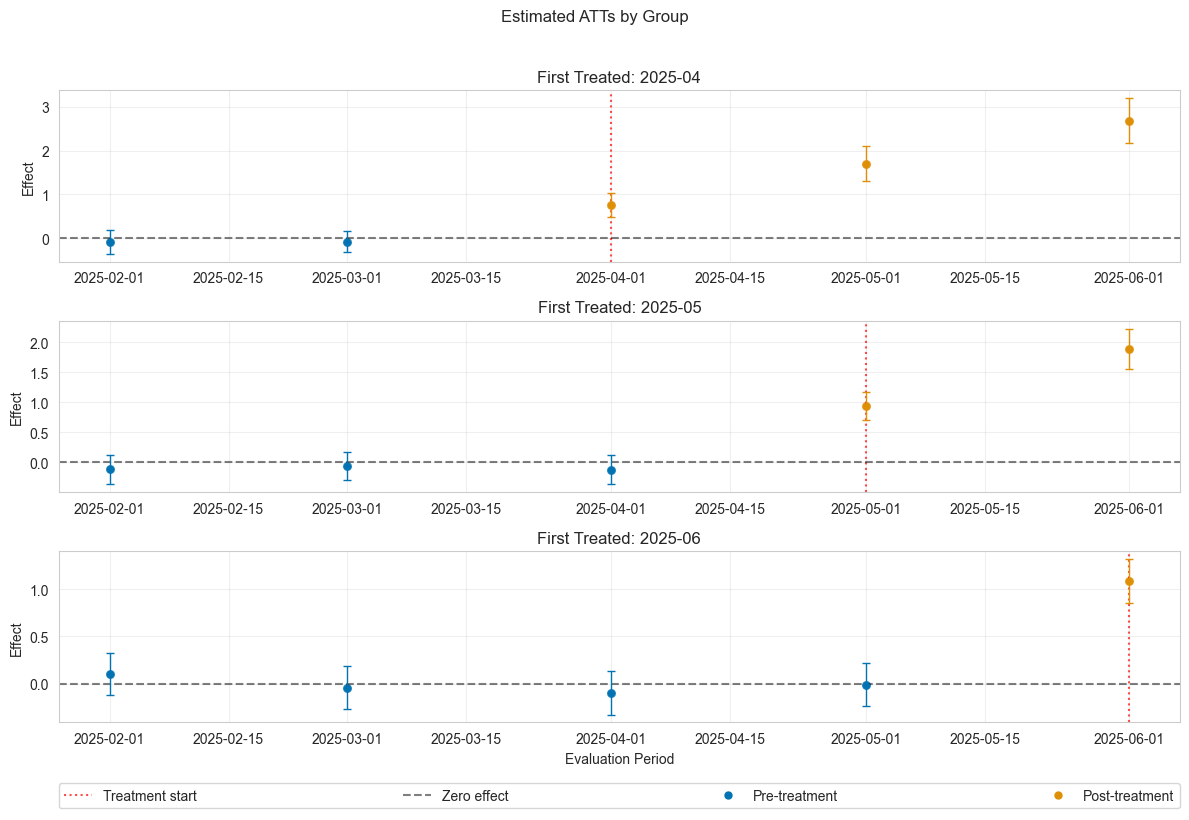

In [25]:
# Visualize all effects with joint confidence intervals
_ = dml_obj.plot_effects()



- Pre-treatment estimates ($t_{\text{eval}} < \mathrm{g}$) should be centered around zero with CIs covering zero
- Post-treatment estimates should reveal increasing effects with exposure time, consistent with $ATT(\mathrm{g},t) = t - \mathrm{g} + 1$.
- Joint confidence intervals from the bootstrap are wider than pointwise CIs, correcting for multiple testing across all group-time combinations.

### Sensitivity Analysis

In [26]:
dml_obj.sensitivity_analysis()
print(dml_obj.sensitivity_summary)

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
                              CI lower  theta lower     theta  theta upper  \
ATT(2025-04,2025-01,2025-02) -0.378837    -0.220286 -0.086982     0.046322   
ATT(2025-04,2025-02,2025-03) -0.354118    -0.211106 -0.079422     0.052263   
ATT(2025-04,2025-03,2025-04)  0.473300     0.630113  0.759907     0.889700   
ATT(2025-04,2025-03,2025-05)  1.285841     1.513396  1.700513     1.887630   
ATT(2025-04,2025-03,2025-06)  2.151407     2.447113  2.685458     2.923804   
ATT(2025-05,2025-01,2025-02) -0.369827    -0.230928 -0.113461     0.004006   
ATT(2025-05,2025-02,2025-03) -0.318081    -0.184344 -0.063834     0.056676   
ATT(2025-05,2025-03,2025-04) -0.377296    -0.238447 -0.121729    -0.005012   
ATT(2025-05,2025-04,2025-05)  0.689112  

### Oracle Comparison

Since we have access to the true potential outcomes, we can compute oracle $ATT(\mathrm{g}, t)$ values and compare them directly with our estimates.

In [27]:
# Oracle: mean ITE for post-treatment group-time combinations
df_post_treatment = df[df["t"] >= df["d"]]
oracle_gt = df_post_treatment.groupby(["d", "t"])["ite"].mean()
print("Oracle ATT(g, t) values:")
print(oracle_gt.round(4))

print("\nEstimated ATT(g, t_pre, t_eval) coefficients:")
print(dml_obj.summary["coef"].round(4))

Oracle ATT(g, t) values:
d           t         
2025-04-01  2025-04-01    0.9973
            2025-05-01    1.9333
            2025-06-01    2.9828
2025-05-01  2025-05-01    0.8676
            2025-06-01    2.0465
2025-06-01  2025-06-01    0.9709
Name: ite, dtype: float64

Estimated ATT(g, t_pre, t_eval) coefficients:
ATT(2025-04,2025-01,2025-02)   -0.0870
ATT(2025-04,2025-02,2025-03)   -0.0794
ATT(2025-04,2025-03,2025-04)    0.7599
ATT(2025-04,2025-03,2025-05)    1.7005
ATT(2025-04,2025-03,2025-06)    2.6855
ATT(2025-05,2025-01,2025-02)   -0.1135
ATT(2025-05,2025-02,2025-03)   -0.0638
ATT(2025-05,2025-03,2025-04)   -0.1217
ATT(2025-05,2025-04,2025-05)    0.9420
ATT(2025-05,2025-04,2025-06)    1.8941
ATT(2025-06,2025-01,2025-02)    0.1009
ATT(2025-06,2025-02,2025-03)   -0.0435
ATT(2025-06,2025-03,2025-04)   -0.0972
ATT(2025-06,2025-04,2025-05)   -0.0114
ATT(2025-06,2025-05,2025-06)    1.0909
Name: coef, dtype: float64


## 4. Effect Aggregation

The individual $ATT(\mathrm{g}, t_{\text{pre}}, t_{\text{eval}})$ estimates are numerous and can be hard to interpret. Aggregation provides summary parameters by combining group-time effects with appropriate weights:

$$\theta_0 = \sum_{\mathrm{g} \in \mathcal{G}} \sum_{t=2}^{\mathcal{T}} \omega_{\mathrm{g},t}\, ATT(\mathrm{g},t)$$

Three aggregation schemes are available, each answering a different question. The `aggregate()` method returns a `DoubleMLDIDAggregation` object that includes an overall summary, aggregated effects, and their weights.

For details, see [Callaway and Sant'Anna (2021)](https://doi.org/10.1016/j.jeconom.2020.12.001) and the [DoubleML user guide](https://docs.doubleml.org/stable/guide/models.html#effect-aggregation).

### 4.1 Group Aggregation

Averages $ATT(\mathrm{g}, t_{\text{eval}})$ over all post-treatment evaluation periods for each group $\mathrm{g}$, i.e. *what is the average treatment effect experienced by units first treated in period $\mathrm{g}$?*

In [28]:
# Oracle group effects
oracle_group = df_post_treatment.groupby("d")["ite"].mean()
print("Oracle group-level ATTs:")
print(oracle_group.round(4))

Oracle group-level ATTs:
d
2025-04-01    1.9711
2025-05-01    1.4571
2025-06-01    0.9709
Name: ite, dtype: float64


================== DoubleMLDIDAggregation Object ==================
 Group Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err         t  P>|t|    2.5 %   97.5 %
1.416854 0.070802 20.011461    0.0 1.278084 1.555624
------------------ Aggregated Effects         ------------------
             coef   std err          t  P>|t|     2.5 %    97.5 %
2025-04  1.715293  0.119349  14.372067    0.0  1.481373  1.949213
2025-05  1.418046  0.090343  15.696211    0.0  1.240976  1.595115
2025-06  1.090882  0.080904  13.483658    0.0  0.932313  1.249451
------------------ Additional Information     ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0



/Users/ruizhechao/Documents/ds-inflow-price-elasticity-service/DoubleML/.venv/lib/python3.12/site-packages/doubleml/did/did_aggregation.py:368: UserWarning:

Joint confidence intervals require bootstrapping which hasn't been performed yet. Automatically applying '.aggregated_frameworks.bootstrap(method="normal", n_rep_boot=500)' with default values. For different bootstrap settings, call bootstrap() explicitly before plotting.



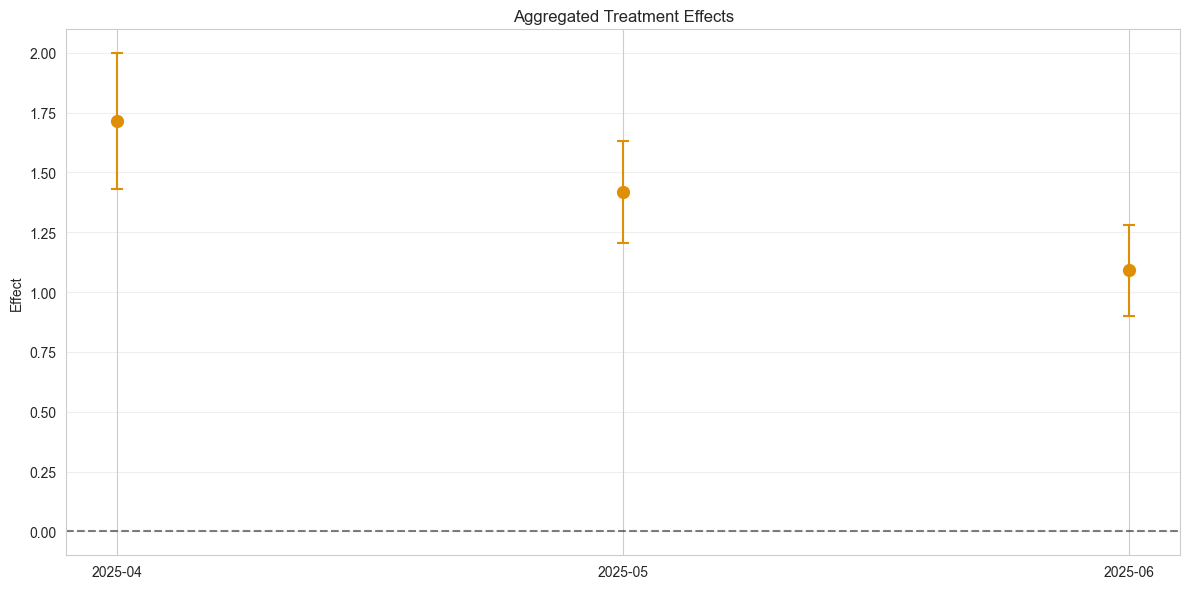

In [29]:
aggregated_group = dml_obj.aggregate(aggregation="group")
print(aggregated_group)
_ = aggregated_group.plot_effects()

Earlier-treated groups (e.g., April 2025) show larger average effects because they accumulate more exposure periods. The overall aggregated effect (top of the output) combines all groups weighted by group size.

### 4.2 Time Aggregation

Averages $ATT(\mathrm{g}, t_{\text{eval}})$ over all treated groups for each calendar period $t_{\text{eval}}$, weighted by group size. Corresponds to *Calendar Time Effects* from the [did-R-package](https://bcallaway11.github.io/did/index.html), i.e. *what is the average treatment effect across all treated units at each point in calendar time?*

In [30]:
# Oracle calendar-time effects
oracle_time = df_post_treatment.groupby("t")["ite"].mean()
print("Oracle calendar-time ATTs:")
print(oracle_time.round(4))

Oracle calendar-time ATTs:
t
2025-04-01    0.9973
2025-05-01    1.4067
2025-06-01    2.0284
Name: ite, dtype: float64


================== DoubleMLDIDAggregation Object ==================
 Time Aggregation 

------------------ Overall Aggregated Effects ------------------
   coef  std err         t  P>|t|    2.5 %   97.5 %
1.33268 0.077947 17.097293    0.0 1.179907 1.485454
------------------ Aggregated Effects         ------------------
             coef   std err          t         P>|t|     2.5 %    97.5 %
2025-04  0.759907  0.095035   7.996094  1.332268e-15  0.573642  0.946171
2025-05  1.325710  0.091975  14.413864  0.000000e+00  1.145443  1.505977
2025-06  1.912425  0.098661  19.383838  0.000000e+00  1.719054  2.105797
------------------ Additional Information     ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0



/Users/ruizhechao/Documents/ds-inflow-price-elasticity-service/DoubleML/.venv/lib/python3.12/site-packages/doubleml/did/did_aggregation.py:368: UserWarning:

Joint confidence intervals require bootstrapping which hasn't been performed yet. Automatically applying '.aggregated_frameworks.bootstrap(method="normal", n_rep_boot=500)' with default values. For different bootstrap settings, call bootstrap() explicitly before plotting.



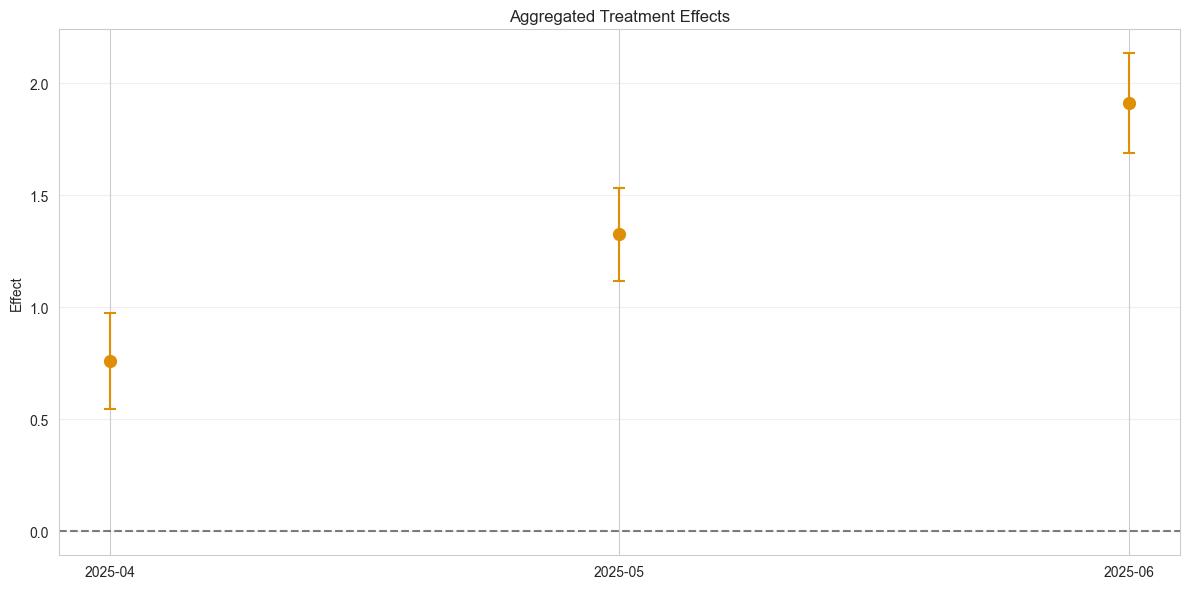

In [31]:
aggregated_time = dml_obj.aggregate("time")
print(aggregated_time)
_ = aggregated_time.plot_effects()

### 4.3 Event Study Aggregation

Aggregates $ATT(\mathrm{g}, t_{\text{eval}})$ by exposure/event time $e = t_{\text{eval}} - \mathrm{g}$, weighted by group size. This is the most common aggregation and visualization in applied DiD, i.e. *how does the treatment effect evolve with time since treatment?*

Negative event times ($e < 0$) represent pre-treatment periods and serve as a built-in parallel trend diagnostic.

In [32]:
# Oracle event-study effects
df["e"] = pd.to_datetime(df["t"]).values.astype("datetime64[M]") - \
    pd.to_datetime(df["d"]).values.astype("datetime64[M]")
oracle_es = df.groupby("e")["ite"].mean()[1:]  # drop NaT group
print("Oracle event-study ATTs:")
print(oracle_es.round(4))

Oracle event-study ATTs:
e
-122 days   -0.0422
-92 days     0.0292
-61 days     0.0467
-31 days     0.0327
0 days       0.9452
31 days      1.9893
59 days      2.9828
Name: ite, dtype: float64


================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err         t  P>|t|    2.5 %   97.5 %
1.802665 0.100493 17.938295    0.0 1.605704 1.999627
------------------ Aggregated Effects         ------------------
               coef   std err          t     P>|t|     2.5 %    97.5 %
-4 months  0.100945  0.077846   1.296725  0.194726 -0.051631  0.253520
-3 months -0.079534  0.057715  -1.378066  0.168183 -0.192653  0.033584
-2 months -0.082412  0.051780  -1.591572  0.111481 -0.183899  0.019075
-1 months -0.072099  0.050143  -1.437856  0.150475 -0.170377  0.026180
0 months   0.926386  0.053287  17.384819  0.000000  0.821946  1.030827
1 months   1.796151  0.102740  17.482487  0.000000  1.594785  1.997518
2 months   2.685458  0.179720  14.942465  0.000000  2.333214  3.037703
------------------ Additional Information     ------------------
Score function: observational
Contro

/Users/ruizhechao/Documents/ds-inflow-price-elasticity-service/DoubleML/.venv/lib/python3.12/site-packages/doubleml/did/did_aggregation.py:368: UserWarning:

Joint confidence intervals require bootstrapping which hasn't been performed yet. Automatically applying '.aggregated_frameworks.bootstrap(method="normal", n_rep_boot=500)' with default values. For different bootstrap settings, call bootstrap() explicitly before plotting.



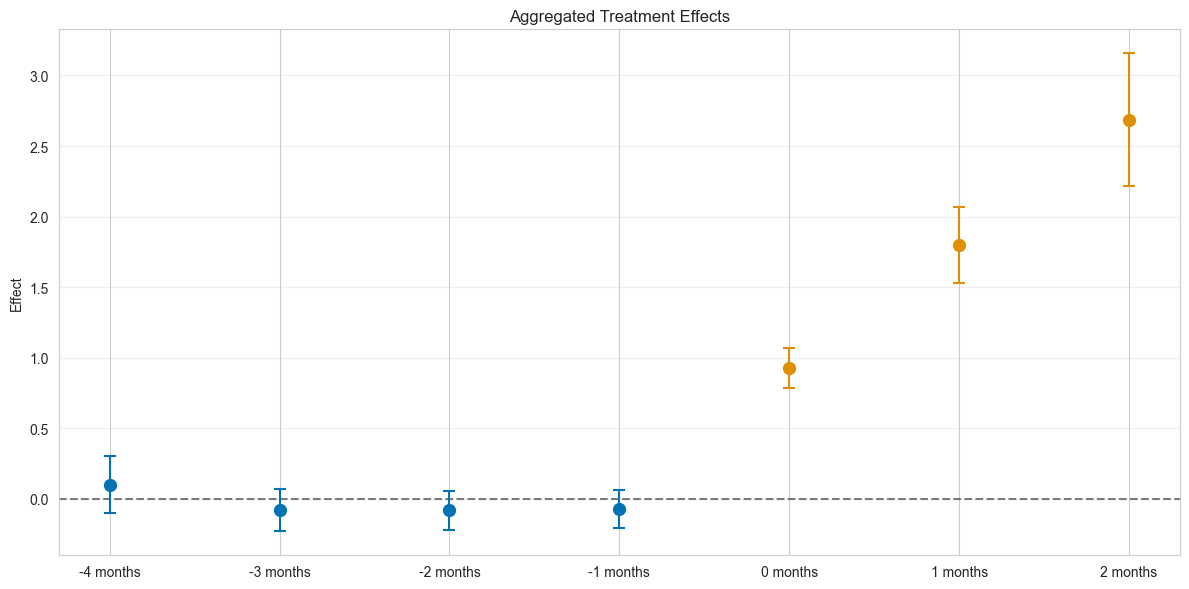

In [33]:
aggregated_eventstudy = dml_obj.aggregate("eventstudy")
print(aggregated_eventstudy)
_ = aggregated_eventstudy.plot_effects()

#### Event Study Interpretation

The event study plot shows:
1. **Pre-treatment** ($e < 0$): effects near zero with CIs covering zero, confirming parallel trends.
2. **At treatment** ($e = 0$): a jump to approximately 1.0, matching the first month of exposure.
3. **Post-treatment** ($e > 0$): linearly increasing effects, consistent with $ATT = e + 1$.

The overall aggregated effect (shown at the top of the print output) averages all $e \geq 0$ periods. The `aggregation_weights` property reveals how each individual $\widehat{ATT}(\mathrm{g}, t_{\text{pre}}, t_{\text{eval}})$ contributes to a given event-time aggregated effect. For example, the $e = 0$ effect combines the estimates for the first treated period of each group, weighted by group size:

In [34]:
# Weights for the e=0 aggregated effect (5th element, after 4 pre-treatment periods)
print("Weights for e=0 aggregated effect:")
print(aggregated_eventstudy.aggregation_weights[4])

print("\nCorresponding individual ATT estimates:")
print(dml_obj.summary["coef"].round(4))

Weights for e=0 aggregated effect:
[0.         0.         0.3453046  0.         0.         0.
 0.         0.         0.33732376 0.         0.         0.
 0.         0.         0.31737164]

Corresponding individual ATT estimates:
ATT(2025-04,2025-01,2025-02)   -0.0870
ATT(2025-04,2025-02,2025-03)   -0.0794
ATT(2025-04,2025-03,2025-04)    0.7599
ATT(2025-04,2025-03,2025-05)    1.7005
ATT(2025-04,2025-03,2025-06)    2.6855
ATT(2025-05,2025-01,2025-02)   -0.1135
ATT(2025-05,2025-02,2025-03)   -0.0638
ATT(2025-05,2025-03,2025-04)   -0.1217
ATT(2025-05,2025-04,2025-05)    0.9420
ATT(2025-05,2025-04,2025-06)    1.8941
ATT(2025-06,2025-01,2025-02)    0.1009
ATT(2025-06,2025-02,2025-03)   -0.0435
ATT(2025-06,2025-03,2025-04)   -0.0972
ATT(2025-06,2025-04,2025-05)   -0.0114
ATT(2025-06,2025-05,2025-06)    1.0909
Name: coef, dtype: float64


## 5. Anticipation

As described in the [Model Guide](https://docs.doubleml.org/stable/guide/models.html#difference-in-differences-models-did), the standard parallel trends assumption requires that treatment has no effect before its actual implementation. In practice, however, units may **anticipate** their treatment and adjust behavior $\delta > 0$ periods before the official treatment date. For example, workers may change behavior after learning about an upcoming policy, even before it takes effect.

Including anticipation periods $\delta > 0$ shifts the pre-treatment reference period further back: instead of using $t_{\text{pre}} = \min(\mathrm{g}, t_{\text{eval}}) - 1$, the framework uses

$$t_{\text{pre}} = \min(\mathrm{g}, t_{\text{eval}}) - 1 - \delta$$

This ensures that the comparison period is not "contaminated" by anticipatory behavior. The `anticipation_periods` parameter in `DoubleMLDIDMulti` controls $\delta$.

### Data with Anticipation

The `make_did_CS2021` DGP allows to include anticipation periods via the `anticipation_periods` parameter. In this case, units anticipate the treatment effect earlier and the exposure effect is increased by the number of anticipation periods. Let us generate a dataset with one period of anticipation ($\delta = 1$).

In [35]:
df_anticipation = make_did_CS2021(
    n_obs=5000, dgp_type=4, n_periods=n_periods,
    n_pre_treat_periods=3, time_type="datetime",
    anticipation_periods=1
)

print(df_anticipation.shape)
df_anticipation.head()

(24348, 10)


,id,y,y0,y1,d,t,Z1,Z2,Z3,Z4
1,0,212.558924,212.558924,214.852413,2025-06-01,2025-01-01,-0.680747,2.317446,0.087511,1.308229
2,0,213.765722,213.765722,214.564785,2025-06-01,2025-02-01,-0.680747,2.317446,0.087511,1.308229
3,0,214.259515,214.259515,216.084711,2025-06-01,2025-03-01,-0.680747,2.317446,0.087511,1.308229
4,0,219.332620,219.332620,219.249311,2025-06-01,2025-04-01,-0.680747,2.317446,0.087511,1.308229
5,0,221.530012,217.765698,221.530012,2025-06-01,2025-05-01,-0.680747,2.317446,0.087511,1.308229


To visualize the anticipation effect, we compute the oracle ITE values and plot them by group over time.

In [36]:
df_anticipation["ite"] = df_anticipation["y1"] - df_anticipation["y0"]
df_anticipation["First Treated"] = df_anticipation["d"].dt.strftime("%Y-%m").fillna("Never Treated")
agg_df_anticipation = df_anticipation.groupby(["t", "First Treated"]).agg(**agg_dictionary).reset_index()
agg_df_anticipation.head()

,t,First Treated,y_mean,y_lower_quantile,y_upper_quantile,ite_mean,ite_lower_quantile,ite_upper_quantile
0,2025-01-01,2025-04,209.583334,192.313300,225.836233,0.000375,-2.377548,2.350212
1,2025-01-01,2025-05,210.598104,194.078575,228.283422,0.008021,-2.214979,2.287111
2,2025-01-01,2025-06,213.113571,196.522496,227.965473,-0.030624,-2.399809,2.410001
3,2025-01-01,Never Treated,216.558396,199.277995,234.358087,-0.065036,-2.347456,2.249546
4,2025-02-01,2025-04,209.828997,184.229010,234.791566,0.041686,-2.243734,2.421850


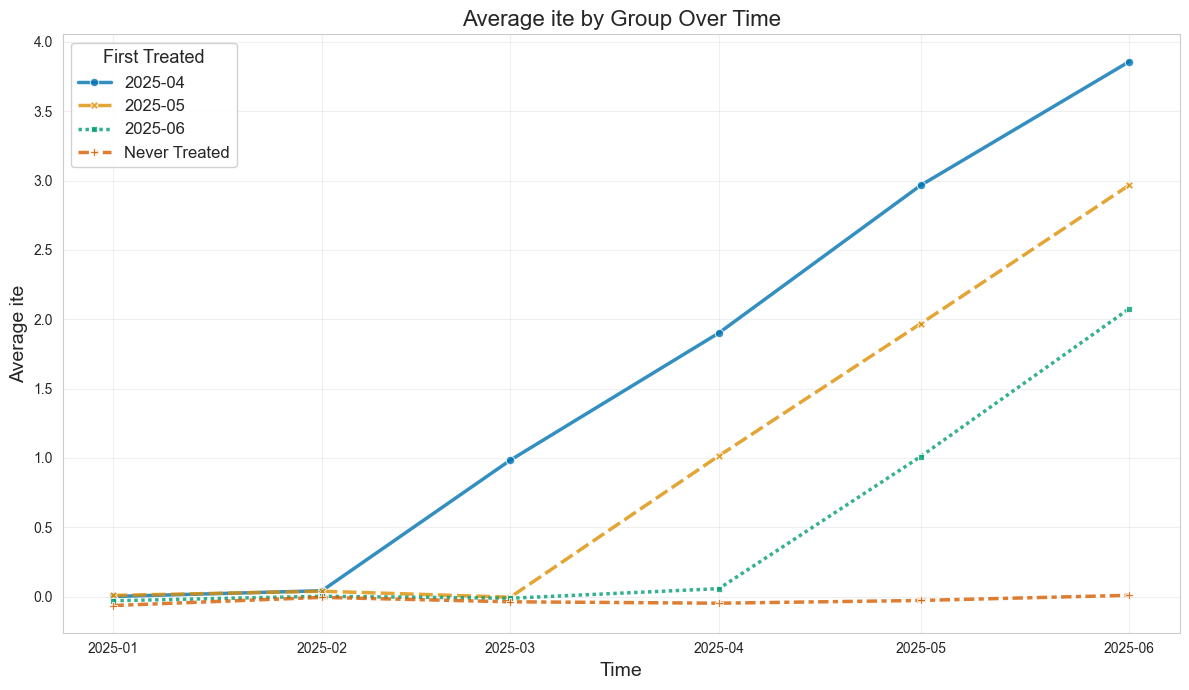

In [37]:
plot_data(agg_df_anticipation, col_name='ite')

One can see that the treatment effect is already non-zero **one period before** the official treatment assignment -- this is the anticipation effect. For example, units first treated in April 2025 show a non-zero ITE already in March 2025.

Initialize a corresponding `DoubleMLPanelData` object for the anticipation dataset.

In [38]:
dml_data_anticipation = DoubleMLPanelData(
    data=df_anticipation,
    y_col="y",
    d_cols="d",
    id_col="id",
    t_col="t",
    x_cols=["Z1", "Z2", "Z3", "Z4"],
    datetime_unit="M"
)

### ATT Estimation without Anticipation Correction

Let us first estimate the model **without** accounting for anticipation (i.e., using the default `anticipation_periods=0`). Since the data contains anticipation effects, we expect the estimates to be biased.

/Users/ruizhechao/Documents/ds-inflow-price-elasticity-service/DoubleML/.venv/lib/python3.12/site-packages/doubleml/double_ml.py:1636: UserWarning:

The estimated nu2 for d is not positive. Re-estimation based on riesz representer (non-orthogonal).



(<Figure size 1200x800 with 4 Axes>,
 [<Axes: title={'center': 'First Treated: 2025-04'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2025-05'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2025-06'}, xlabel='Evaluation Period', ylabel='Effect'>])

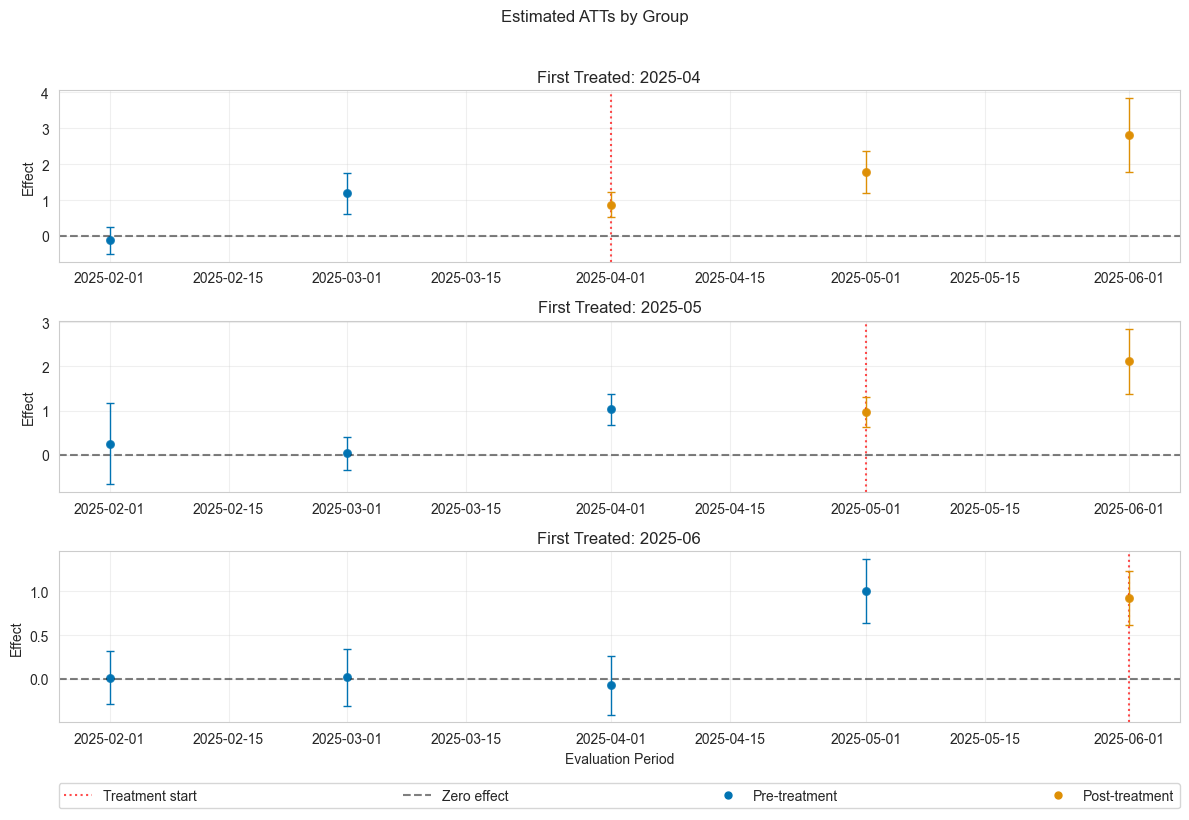

In [39]:
dml_obj_anticipation = DoubleMLDIDMulti(dml_data_anticipation, **default_args)
dml_obj_anticipation.fit()
dml_obj_anticipation.bootstrap(n_rep_boot=5000)
dml_obj_anticipation.plot_effects()

The effects are obviously biased: the pre-treatment estimates are no longer near zero, and the post-treatment effects are distorted. This happens because the model uses a contaminated pre-treatment period as reference.

### ATT Estimation with Anticipation Correction

To correctly account for anticipation, we set `anticipation_periods=1`. This shifts the pre-treatment reference period back by one additional period, ensuring that the comparison is made against a truly "clean" baseline. Correspondingly, the outcome regression and the definition of not-yet-treated units are adjusted.

(<Figure size 1200x800 with 4 Axes>,
 [<Axes: title={'center': 'First Treated: 2025-04'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2025-05'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2025-06'}, xlabel='Evaluation Period', ylabel='Effect'>])

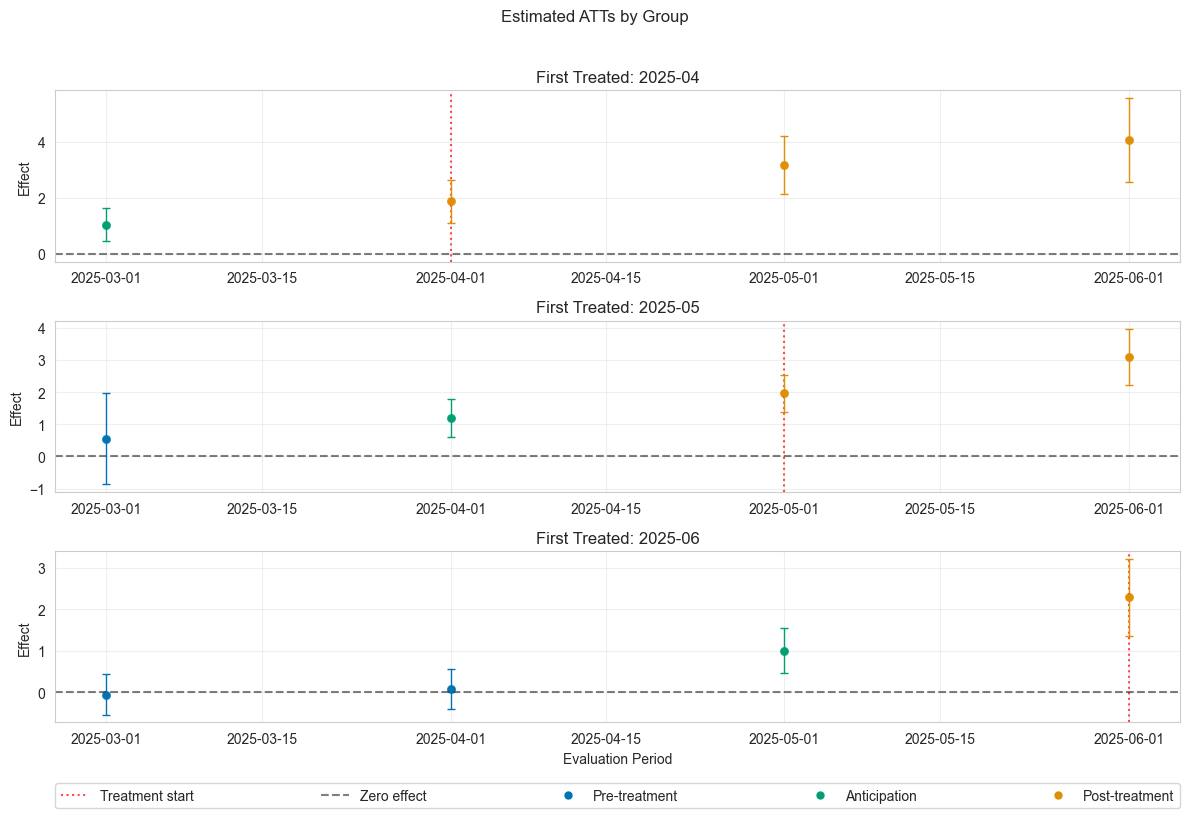

In [40]:
dml_obj_anticipation_corrected = DoubleMLDIDMulti(
    dml_data_anticipation,
    **(default_args | {"anticipation_periods": 1})
)
dml_obj_anticipation_corrected.fit()
dml_obj_anticipation_corrected.bootstrap(n_rep_boot=5000)
dml_obj_anticipation_corrected.plot_effects()

With `anticipation_periods=1`, the corrected model recovers unbiased $ATT(\mathrm{g}, t_{\text{eval}})$ estimates. The pre-treatment effects are again close to zero, and the post-treatment effects align with the oracle values. This demonstrates that correctly specifying the number of anticipation periods is crucial when anticipation is present in the data.

## 6. Impact of Methodological Choices

Two key choices affect the estimation results: (a) the control group definition, and (b) the learner specification for nuisance functions. We examine both, benchmarking against the oracle values.

### 6.1 Control Group: Never Treated vs. Not Yet Treated

The control group $\mathcal{C}$ determines which units serve as the comparison:

- **`"never_treated"`** ($G_i = \infty$): Only units never treated during the observation window. Requires a never-treated group in the data.
- **`"not_yet_treated"`** ($G_i > t_{\text{eval}}$): Units not yet treated at the evaluation period. Uses more comparison units (potentially tighter CIs), but requires a stronger assumption: units that will eventually be treated must satisfy parallel trends even before their own treatment.

For a detailed discussion and recommendations, see [Callaway and Sant'Anna (2021)](https://doi.org/10.1016/j.jeconom.2020.12.001).

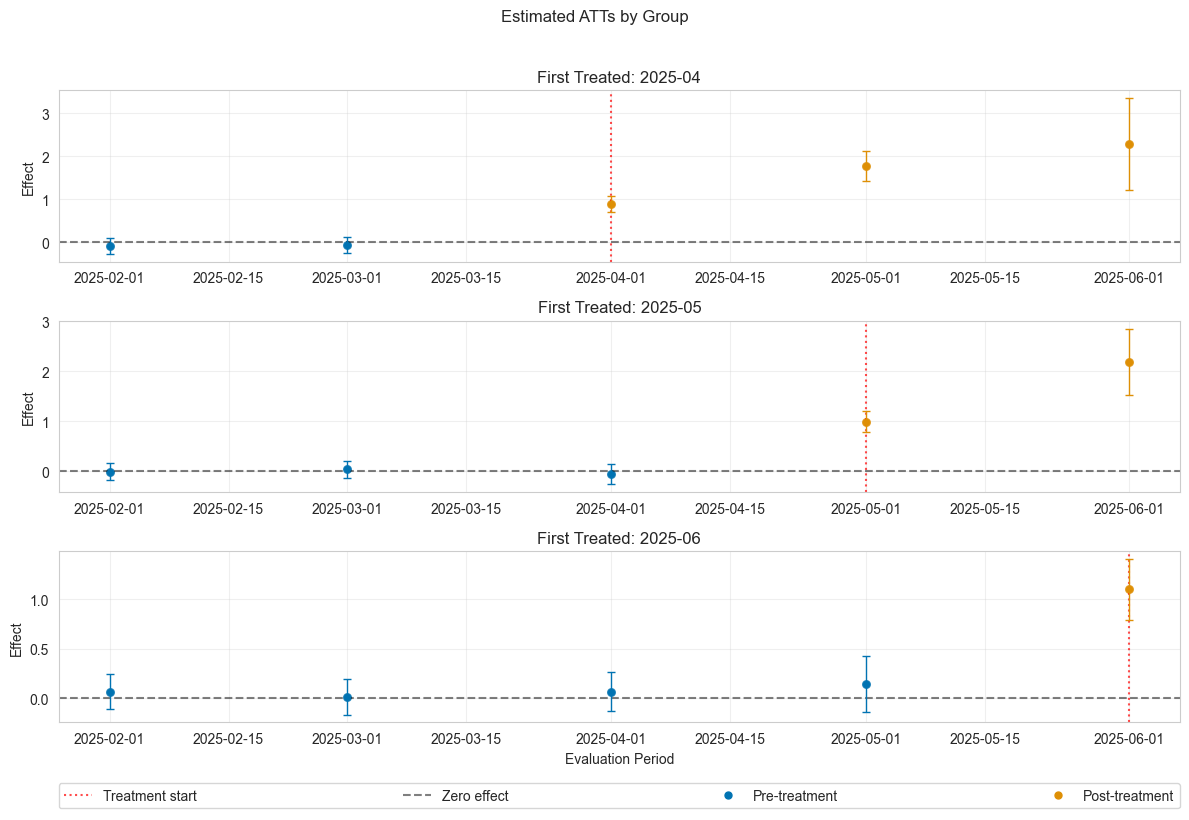

In [41]:
np.random.seed(42)
dml_obj_nyt = DoubleMLDIDMulti(
    dml_data,
    **(default_args | {"control_group": "not_yet_treated"})
)
dml_obj_nyt.fit()
dml_obj_nyt.bootstrap(n_rep_boot=5000)
_ = dml_obj_nyt.plot_effects()

In this DGP (where all assumptions hold by construction), both control group definitions produce valid estimates close to the oracle. Compare the plot above with the `never_treated` result from Section 3. The `not_yet_treated` control group uses a larger comparison sample, which may yield slightly tighter confidence intervals.

In [42]:
comp_table = dml_obj_nyt.summary[["coef", "std err"]]\
    .join(dml_obj.summary[["coef", "std err"]], lsuffix="_not_yet", rsuffix="_never")

print("Comparison of ATT estimates between 'not yet treated' and 'never treated' control groups:")
comp_table.round(4)

Comparison of ATT estimates between 'not yet treated' and 'never treated' control groups:


,coef_not_yet,std err_not_yet,coef_never,std err_never
"ATT(2025-04,2025-01,2025-02)",-0.0779,0.0652,-0.0870,0.0961
"ATT(2025-04,2025-02,2025-03)",-0.0584,0.0621,-0.0794,0.0868
"ATT(2025-04,2025-03,2025-04)",0.8894,0.0611,0.7599,0.0950
"ATT(2025-04,2025-03,2025-05)",1.7669,0.1188,1.7005,0.1383
"ATT(2025-04,2025-03,2025-06)",2.2827,0.3663,2.6855,0.1797
"ATT(2025-05,2025-01,2025-02)",-0.0082,0.0589,-0.1135,0.0844
"ATT(2025-05,2025-02,2025-03)",0.0371,0.0595,-0.0638,0.0813
"ATT(2025-05,2025-03,2025-04)",-0.0591,0.0691,-0.1217,0.0844
"ATT(2025-05,2025-04,2025-05)",0.9927,0.0697,0.9420,0.0821
"ATT(2025-05,2025-04,2025-06)",2.1844,0.2282,1.8941,0.1161
